# Locating informed wallets on Hyperliquid — markout screen

**Objective:** identify mid/low-frequency traders whose position entries systematically precede
favorable moves (positive markout), i.e. *informed flow*, from the full exchange tape.

**Data:** complete Hyperliquid perp tape (every fill, both counterparties) from the public S3
node archive; 5-minute price bars derived from the tape itself; HL hourly funding history.
All perps included (BTC/ETH/SOL/HYPE + all alts). Spot and builder markets excluded.

**Status: PRELIMINARY (train window Oct 2025–Mar 2026).** The held-out confirmation
(Apr–Jun 2026, pre-registered, single look) is pending — see final section. Nothing in this
notebook reads test-window data.

*Method integrity: post-fill pricing throughout (entries can never be priced at or before the*
*leader's own fill), and the pipeline passed three adversarial audit rounds*
*(babylon repo: `audit/edge3/PIPELINE_AUDIT*.md`).*


In [94]:
# regenerate all figures from the pipeline artifacts (train-side only)
import subprocess, sys
print(subprocess.run([sys.executable, 'report_figs.py'], capture_output=True, text=True).stdout)


figures written: ['01_funnel.png', '02_term_structure.png', '03_wallet_dist.png', '04_monthly_vs_btc.png', '05_direction.png', '06_coins.png', '07_shapes.png', '08_roster_monthly_activity.png', '09_active_months_hist.png', '10_freq_size_dist.png', '11_monthly_heatmap.png', '12_cohort_dists.png', '13_tape_overview.png', '14_demographics.png', '15_entry_style.png', '16_entry_timing.png', '17_sizing.png', '18_term_heatmap.png', '19_coentry.png', '20_persistence.png', '21_vignettes.png']
extra figures 08-11 written
fig 12 written



## 1. The filter funnel — targeting human-scale traders
Volume *ranking* selects HFT and market-makers (uncopyable execution alpha). Instead we use an
**activity band** on the train window: 150–20,000 taker orders, ≥25 active days, 0.5–15
orders/day, ≥$500 mean order. TWAP/liquidation fills excluded from order counting (kept in
position reconstruction).


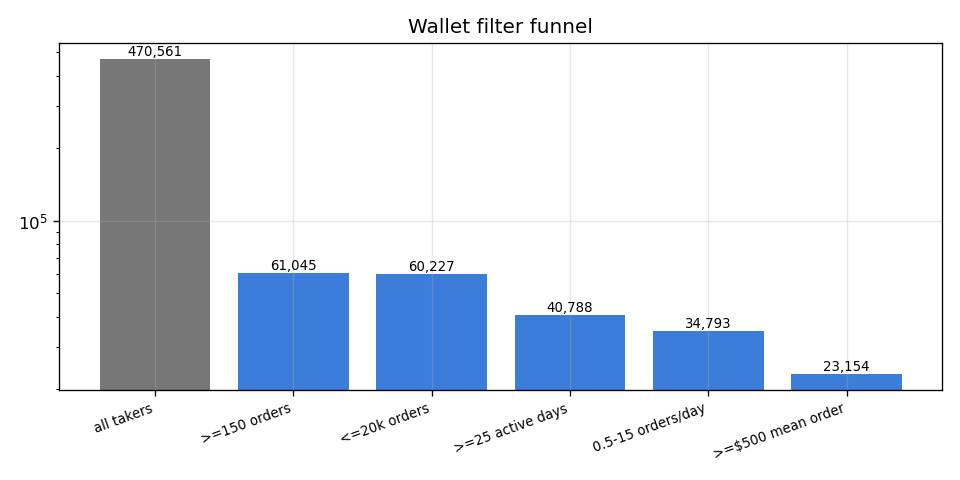

In [95]:
from IPython.display import Image, display
display(Image('report_figs/01_funnel.png'))


### Cohort distributions: all takers → eligible → top-50
What each stage does to the population. Filters (grey→blue): remove the one-shot tourists
(months-active, active-days panels) and dust (order size). Ranking (blue→green): within the
eligible band, the top-50 skew to larger size ($100k–$1M mean orders — whales, but human-
frequency ones), slightly higher frequency, near-universal 6/6-month presence, and (by
construction) the right tail of 24h markout skill.


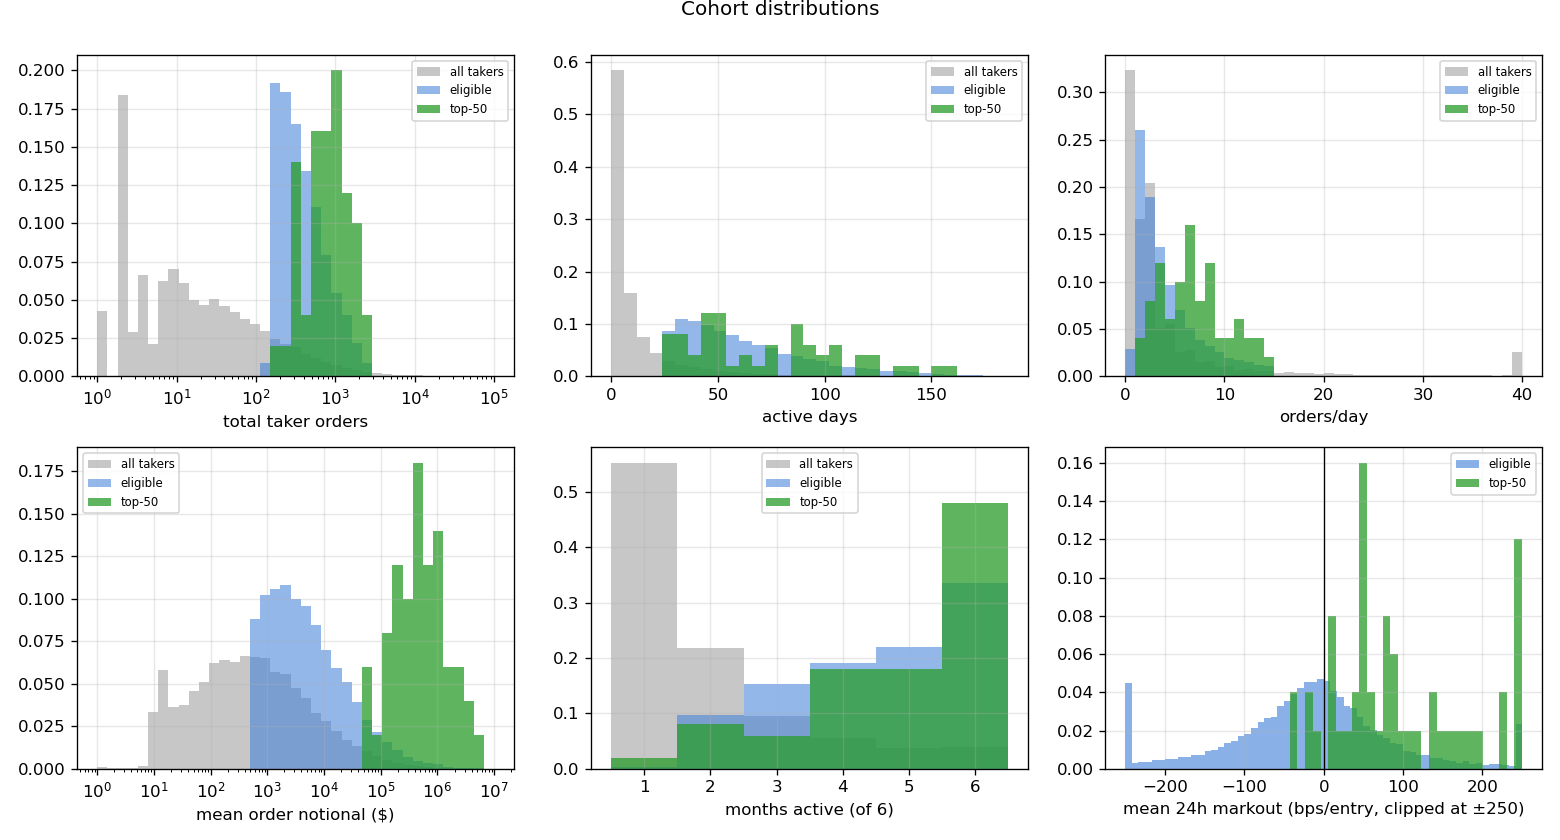

In [96]:
display(Image('report_figs/12_cohort_dists.png'))


## 1b. The data itself
Left: listed perps per day (the spring 2026 listing wave is visible). Right: monthly taker
volume and distinct wallet counts. Below: wallet lifespans are short (most takers are
tourists) and volume is extremely concentrated — ~1% of wallets do most of the notional.


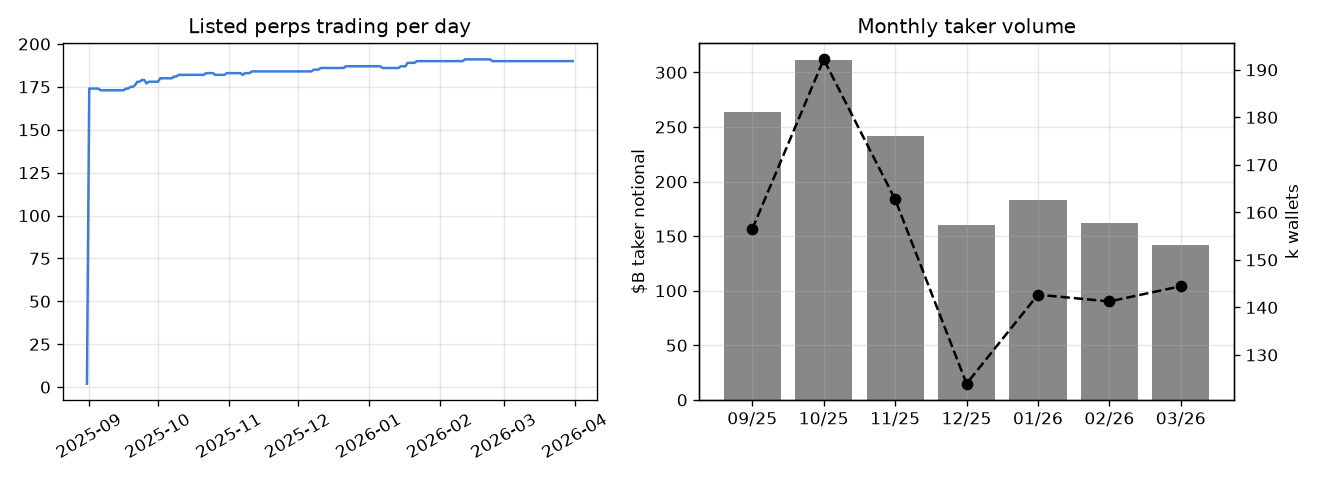

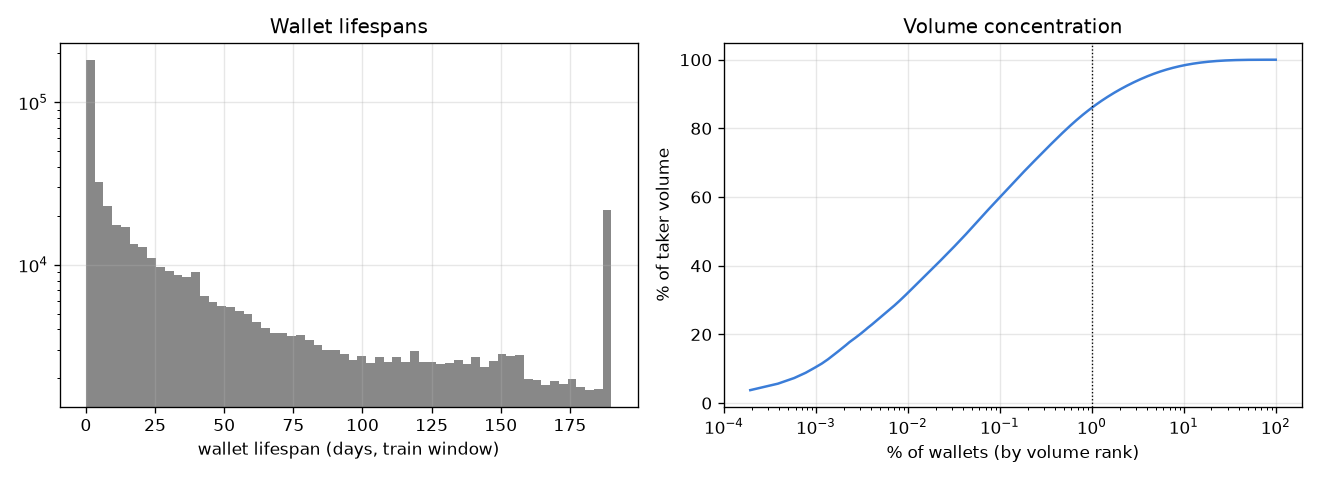

In [97]:
display(Image('report_figs/13_tape_overview.png'))
display(Image('report_figs/14_demographics.png'))


## 2. The core result — markout term structure
Every position-opening taker fill is scored by price change from the first 5m bar strictly
*after* the fill to each horizon. The **field is anti-informed** (entries precede adverse
moves, worsening with horizon). The top-50 (ranked by train 24h dollar markout PnL) show the
opposite: profit that *builds* over hours-to-days and barely exists in the first hour —
the positional (copyable) profile, not execution alpha.


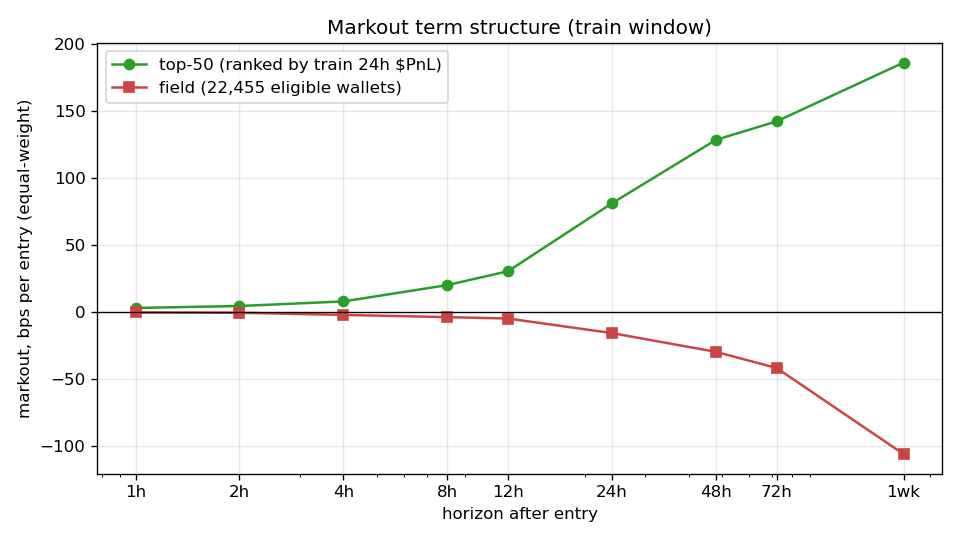

In [98]:
display(Image('report_figs/02_term_structure.png'))


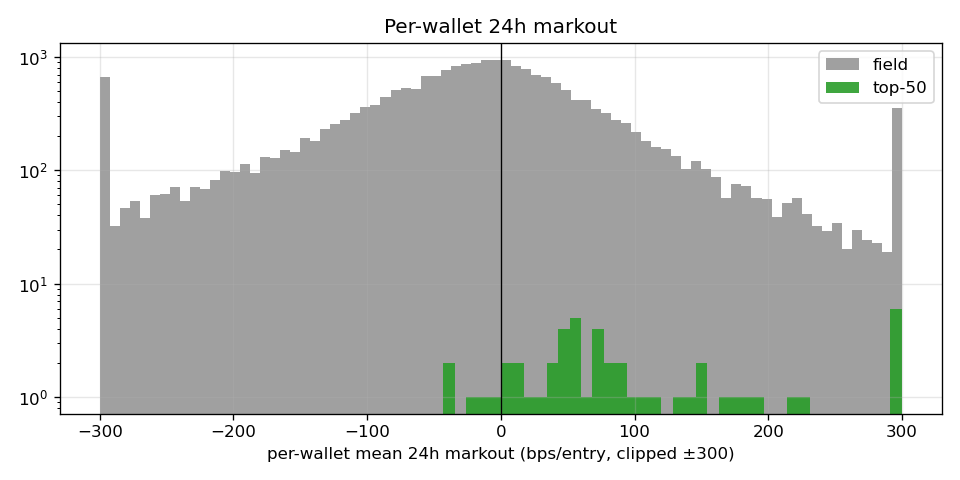

In [99]:
display(Image('report_figs/03_wallet_dist.png'))


## 3. Not a bull-market artifact
The train window was a **bear** (BTC ≈ −40% cumulative). The roster was profitable in every
monthly bucket, with the largest PnL in the crash months. Both sides work: long entries
+74bp, short entries +92bp @24h. 30/50 wallets trade both directions.


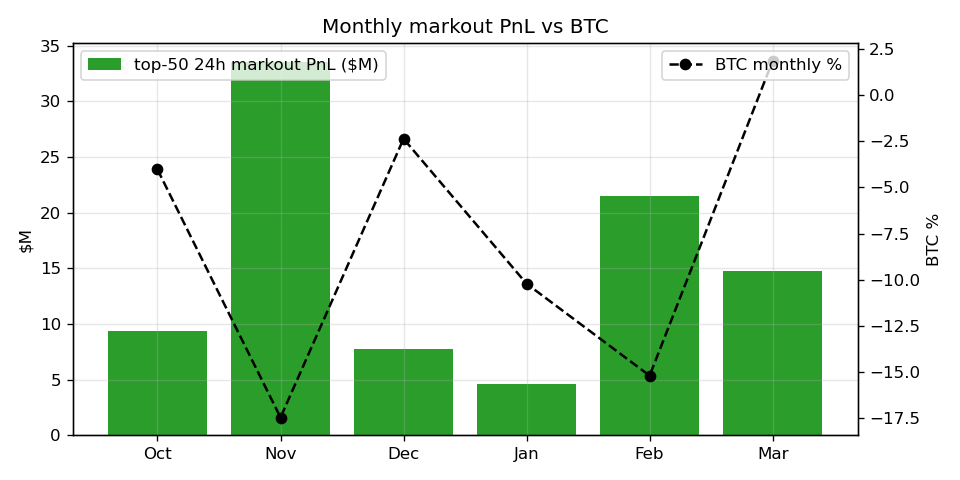

In [100]:
display(Image('report_figs/04_monthly_vs_btc.png'))


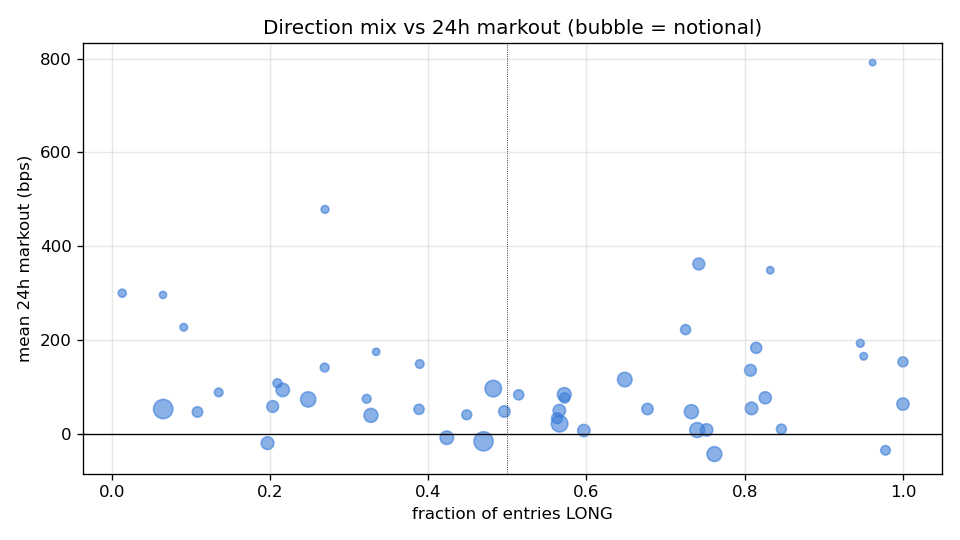

In [101]:
display(Image('report_figs/05_direction.png'))


## 3b. Activity & persistence — not one lucky month
Skeptic's questions answered directly: how many of the top-50 traded each month (all ~50,
every month); how activity persistence compares to the field (top-50 are present in more of
the 6 train months); where the roster sits inside the frequency/size filter band; and the
per-wallet monthly PnL heatmap — mostly green across the bear months, with honest red cells
(median wallet profitable in ~2/3 of its months; these are real traders, not a fitted grid).


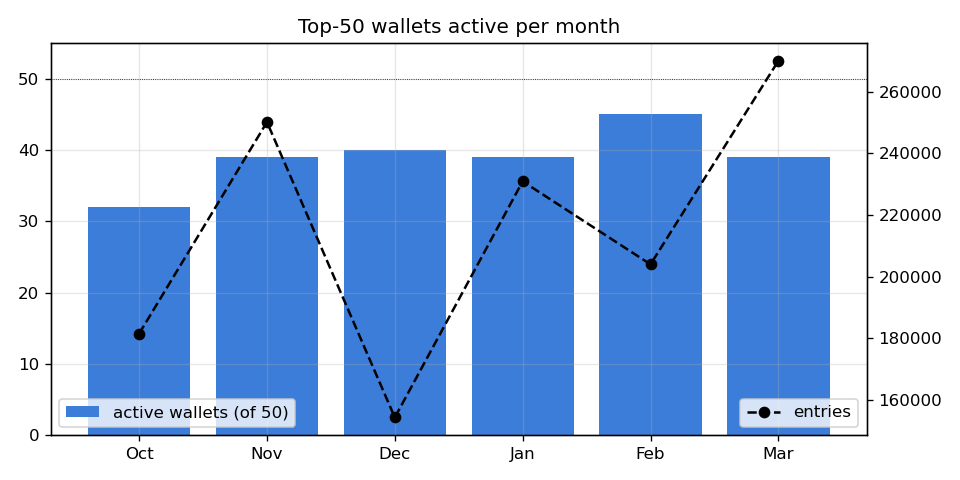

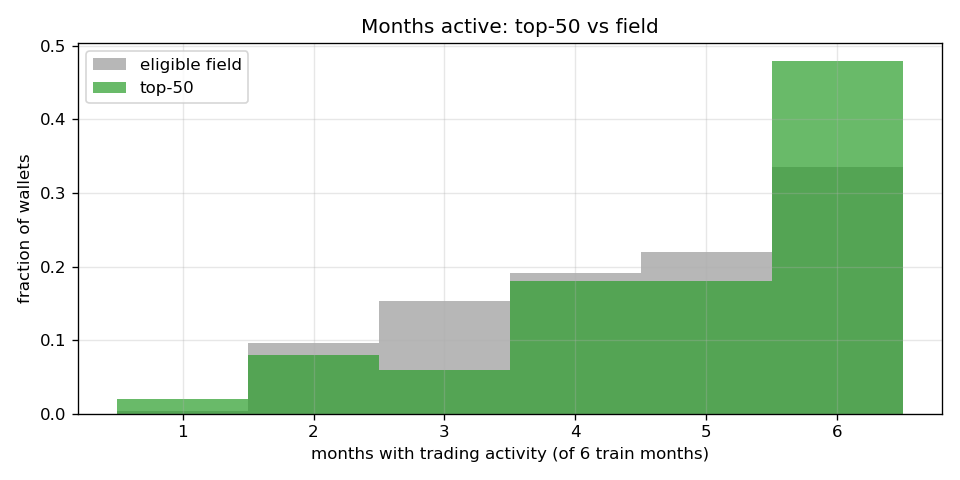

In [102]:
from IPython.display import Image, display
display(Image('report_figs/08_roster_monthly_activity.png'))
display(Image('report_figs/09_active_months_hist.png'))


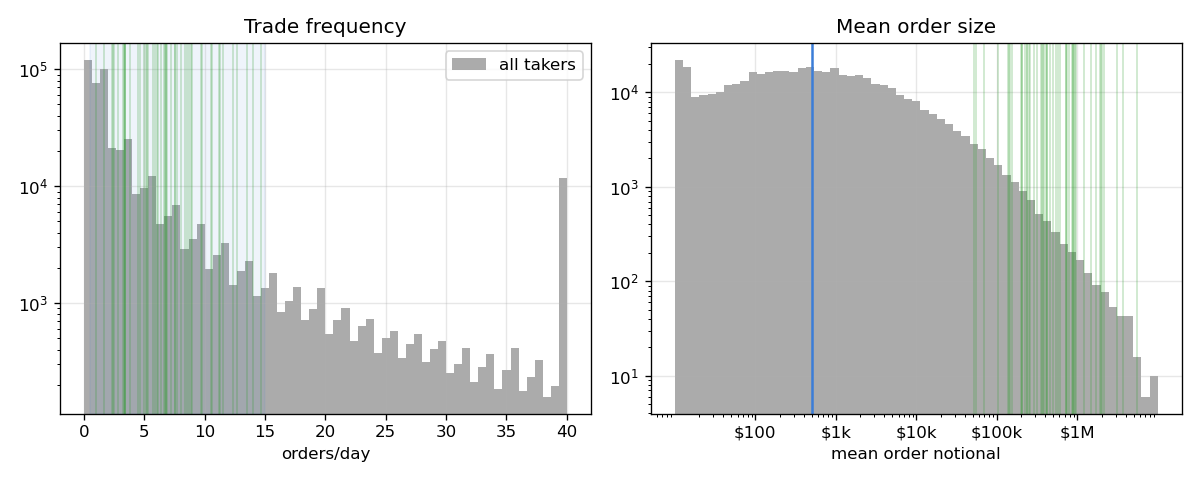

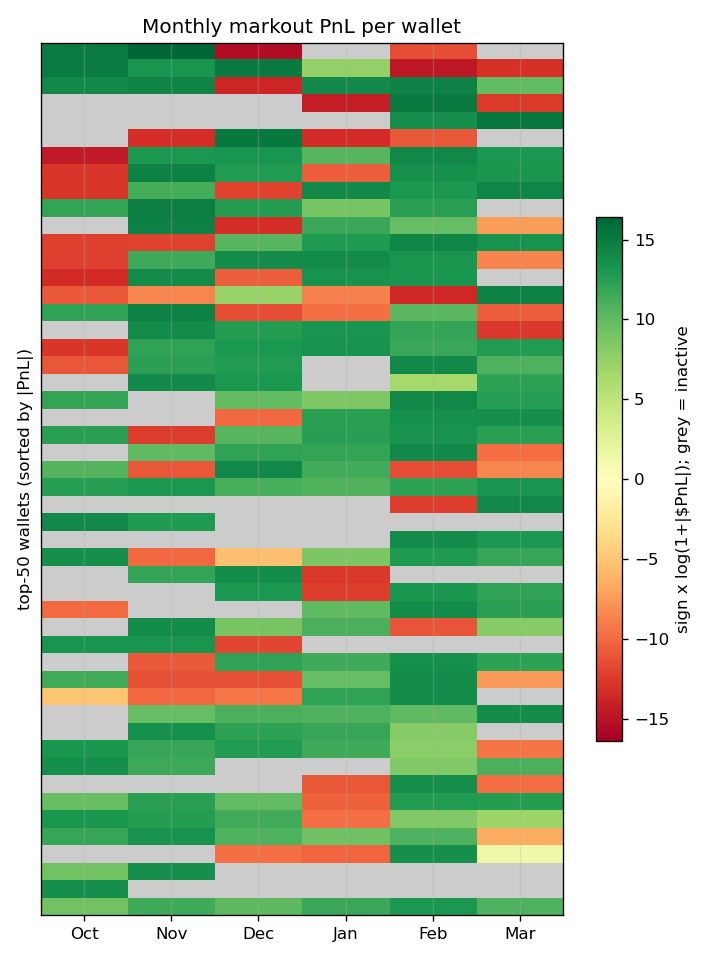

In [103]:
display(Image('report_figs/10_freq_size_dist.png'))
display(Image('report_figs/11_monthly_heatmap.png'))


## 4. What they trade — majors, by specialization
87% of roster markout PnL is in majors (ETH 39%, BTC 36%). Per-wallet concentration is high
(median 84% from one coin) but that overwhelmingly means *ETH/BTC specialists*, not one-alt
lottery tickets. Known flags: ZEC (~12%) was a genuine late-2025 runner (luck candidates);
~36% of PnL sits on crowded coin-days (≥10 of 50 wallets entering together) — the roster is
partly a smaller number of shared macro calls.


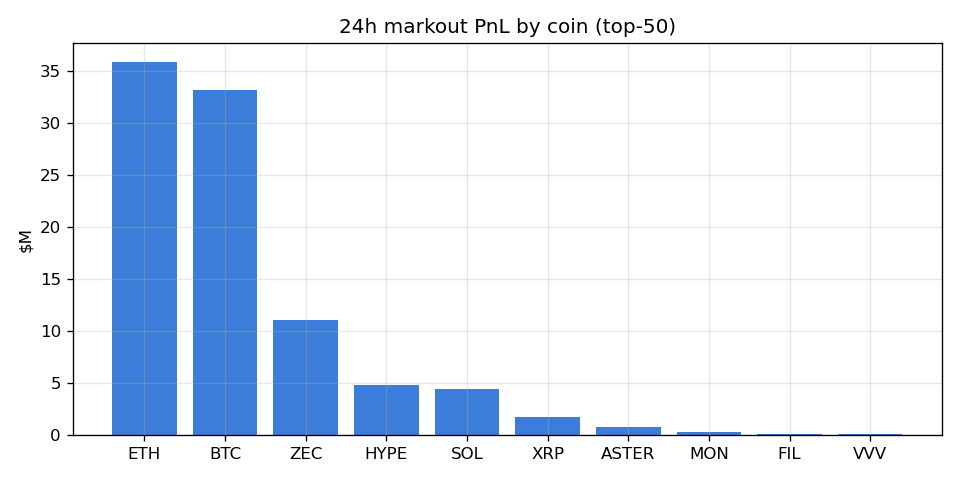

In [104]:
display(Image('report_figs/06_coins.png'))


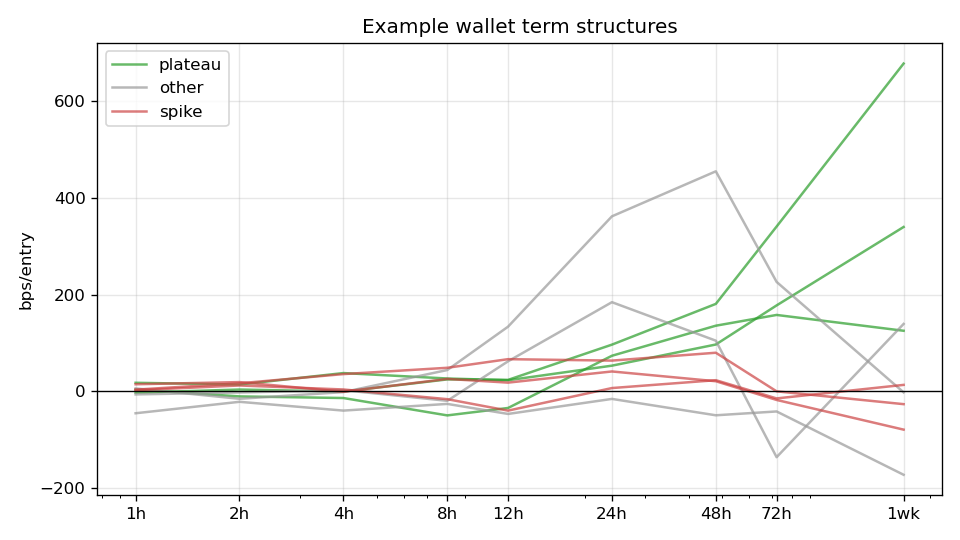

In [105]:
display(Image('report_figs/07_shapes.png'))


## 4b. Wallet fingerprints
Who are these 50, behaviorally?
- **Entry style:** 38/50 enter WITH prior-4h momentum, 12/50 against it — mostly trend-riders,
  not dip-buyers. In a trending train window this also means part of their markout rides
  continuation (see caveats).
- **Timing:** entry heatmap by UTC hour/weekday.
- **Sizing:** conviction-sizers vs uniform-sizers; the red points (negative per-entry skill,
  positive dollar PnL) are the size-timers.
- **Term-structure heatmap:** every wallet's horizon profile in one image.
- **Co-entry overlap:** block structure = herds making the same calls; independent minds are rare.
- **Within-train persistence (IMPORTANT):** half-1 vs half-2 per-entry skill correlation is
  ~0 (r=-0.04; 49% positive in both halves). Per-entry skill did NOT persist across train
  halves for this roster — a genuinely negative pre-verdict indicator for the equal-weight
  test, partly attenuated by selection/range-restriction effects. The dollar-weighted edge
  (sizing skill) is not tested by this scatter.
- **Vignettes:** two consistent wallets' entries on their main coin.


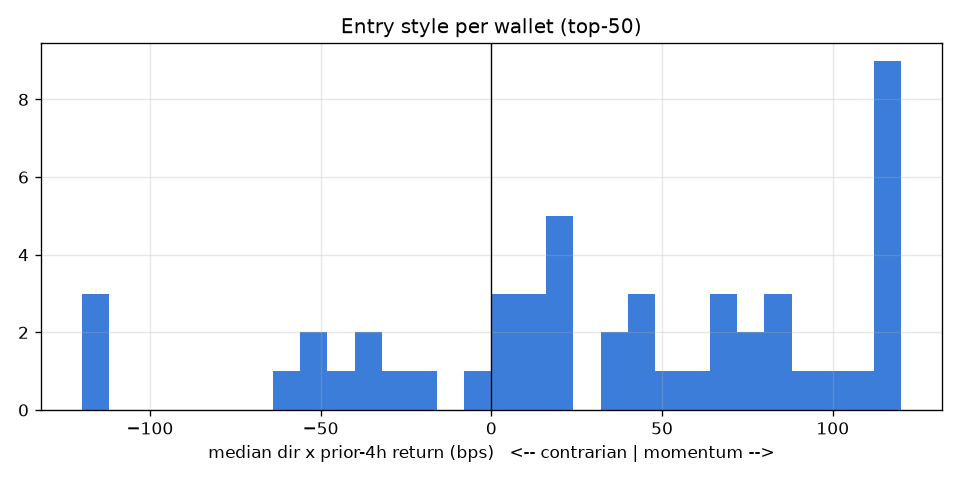

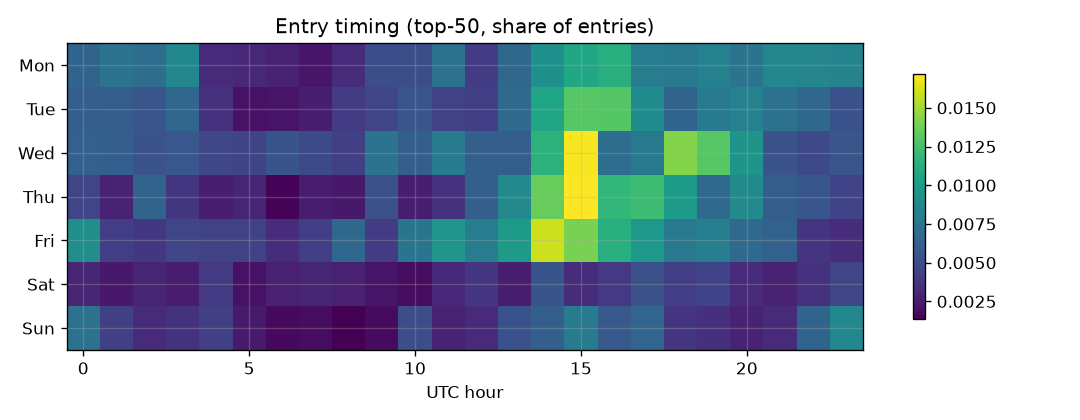

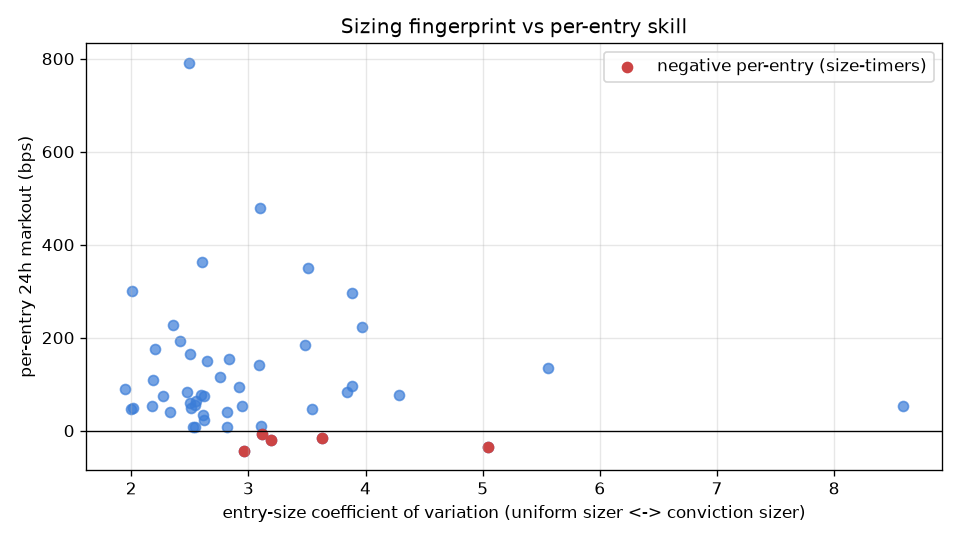

In [106]:
display(Image('report_figs/15_entry_style.png'))
display(Image('report_figs/16_entry_timing.png'))
display(Image('report_figs/17_sizing.png'))


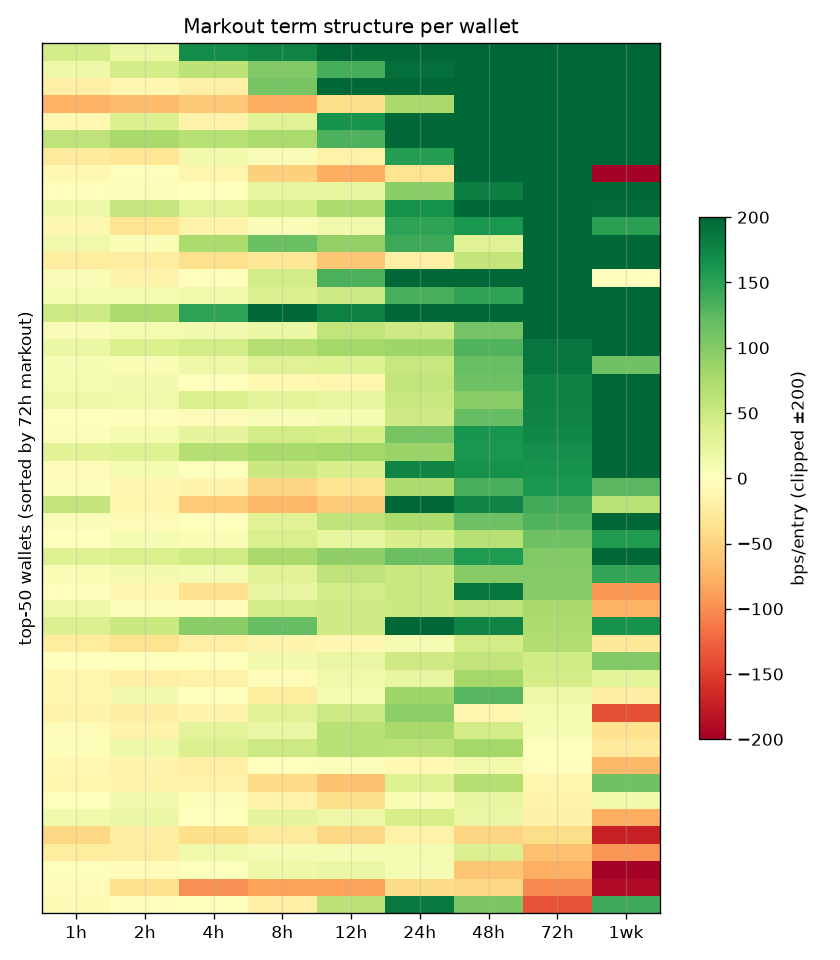

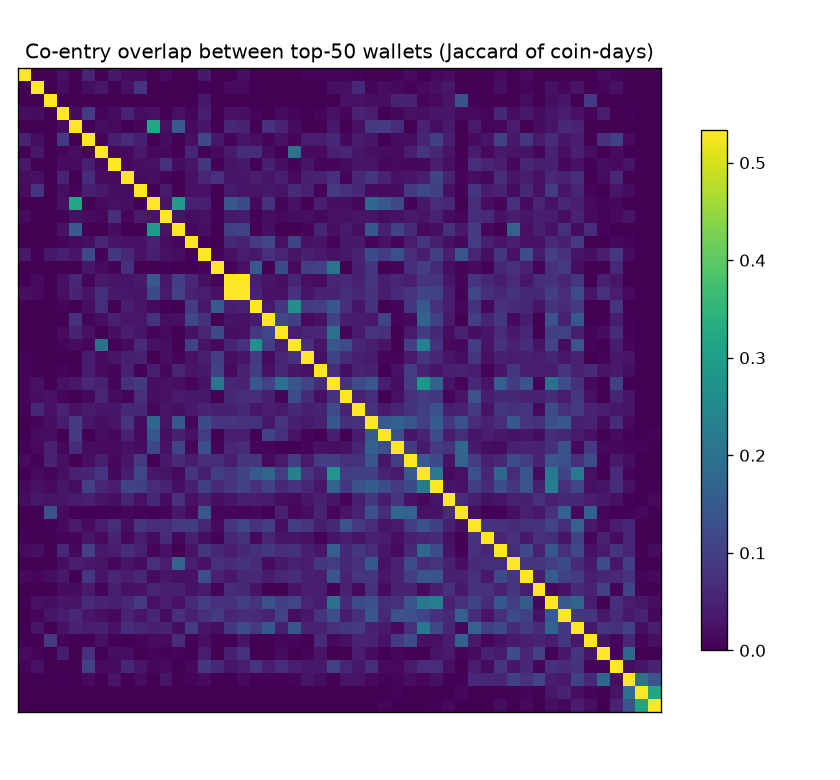

In [107]:
display(Image('report_figs/18_term_heatmap.png'))
display(Image('report_figs/19_coentry.png'))


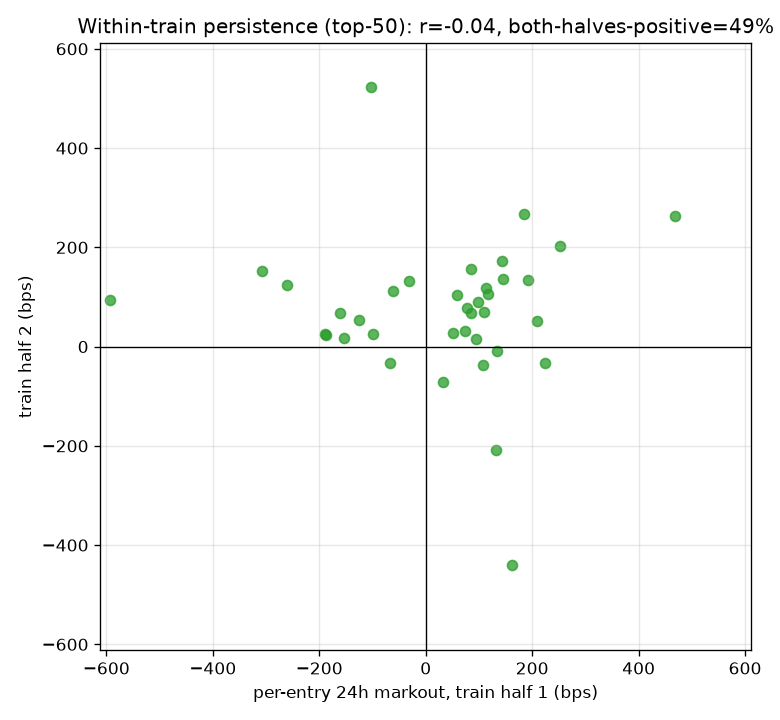

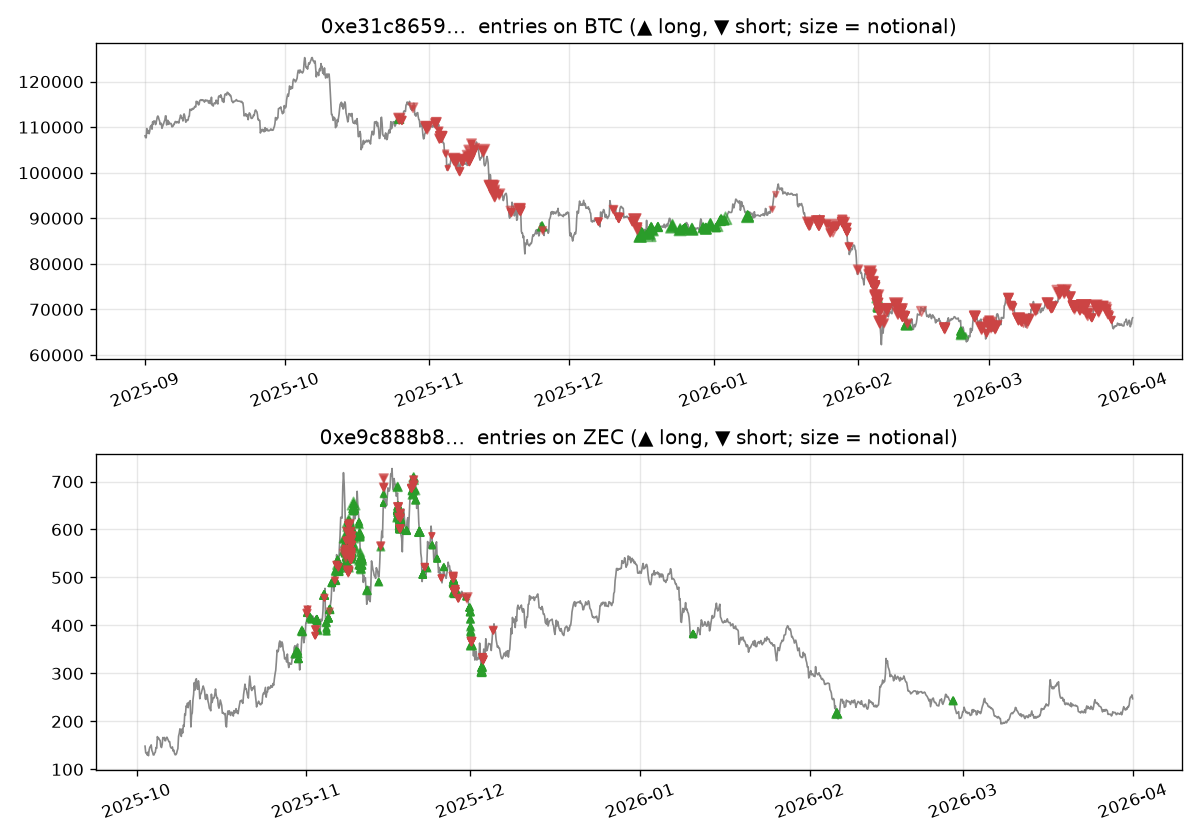

In [108]:
display(Image('report_figs/20_persistence.png'))
display(Image('report_figs/21_vignettes.png'))


## 5. What these numbers can and cannot claim (read before quoting)
- **Winner's curse:** a top-50 *selected on* train PnL always looks spectacular on train data.
  The train-side numbers identify *candidates*, they do not establish skill.
- **Shape is suggestive, not probative:** a plateau after the ranking horizon is also what
  selected noise looks like; post-24h growth partly reflects short-tilt × bear drift.
- **Raw markouts** (not drift-adjusted): the held-out test controls this with same-window
  placebo rosters.
- **Wallet ≠ trader:** address rotation means wallet-level persistence is a lower bound;
  entities that rotate addresses are invisible to an 8-month screen.
- Wallets inactive out-of-sample are *missing data*, not failures; roster liveness is
  reported separately from per-entry edge.

- **Size-timers:** 5 of the top-50 have negative per-entry markout but positive per-dollar
  markout — their edge is in WHEN they size up. The decision statistic (equal-weight) tests
  their weakest axis; a size-weighted, size-matched design is a round-two question.
- **Monthly and per-side splits are calendar-month, train-bars-only** (audit round 4).



**RESULT (2026-07-02/03, sealed Apr–Jun 2026 window): FAIL — the null holds.**

- Markout cell: roster +24.1bp/entry @24h vs placebo median −17.9 → **84.5th pct** (bar: 97.5). FAIL.
- Follower cell: copier Sharpe **−0.03**; bootstrap CI −3.70; placebo pct 81.7%; reverses ex-best-month. FAIL on all conditions.
- Walk-forward: 3/5 folds above placebo median, pooled z +0.37 (bar: ≥4/5 and >1.64). FAIL. June: −90bp/entry.
- Declared signal tournament: no winner. Sole standout: **ex-majors selection (F)** — positive in all 5 registered folds
  including June (+0.97 pooled, +0.98 activity-matched), but below the 1.64 bar. Advances to the July battery as a
  candidate, alongside MM-crossing (H4) and crowd-matched certification (H6).

**Conclusion:** after artifact-corrected, adversarially audited, pre-registered out-of-sample testing, generic
wallet-selection alpha on Hyperliquid is NOT supported. Copyability ≠ identifiability: majors transfer mechanically
at low cost, but wallet selection on majors performance produces no reliable alpha. Evidence suggests alpha, if
present, is conditional (wallet × venue × behavior × regime) rather than wallet-global. The remaining hypotheses
are narrow, frozen, and testable on July data.


In [109]:
# top-50 candidate wallet list (train ranking) -> csv
import json
import polars as pl
rows = [json.loads(l) for l in open('../scratch_conv/mlscreen/markout2.jsonl') if l.strip()]
i24 = 5  # index of 24h in [1,2,4,8,12,24,48,72,168]
el = [(r['w'], r['train_pnl'][i24], r['train_n'][i24]) for r in rows if r['train_n'][i24] >= 30]
top = sorted(el, key=lambda x: -x[1])[:50]
df = pl.DataFrame({'wallet': [t[0] for t in top],
                   'train_24h_pnl_usd': [round(t[1]) for t in top],
                   'train_entries': [t[2] for t in top]})
df.write_csv('report_figs/top50_wallets.csv')
df.head(10)

wallet,train_24h_pnl_usd,train_entries
str,i64,i64
"""0xace0a4c087f7f199328fb1e38d8d…",10825677,42350
"""0xbf732ea04197942783e34730ed6e…",5260262,68220
"""0x15a4f009bb324a3fb9e36137136b…",4991422,22887
"""0x0ddf9bae2af4b874b96d287a5ad4…",3991244,51921
"""0xe9c888b87f2c8723a08d105a18bc…",3357360,24801
"""0x9e8b1e51c642f4c8b87c6ba11c53…",3281319,19494
"""0xd985bd504d737c6533335dfa4ad7…",2799709,37189
"""0x152e41f0b83e6cad4b5dc730c1d6…",2486051,9311
"""0x149277a32f92dcc0c362be7429be…",2407014,15665
